## Setup & Data Loading

We import the necessary libraries and load the five relevant tables from the Instacart dataset. The dataset also contains `order_products_train`, which holds each user's most recent order and is intended for purchase prediction models. Since our goal is to analyse purchasing patterns rather than build a predictive model, we only use `order_products_prior`, which contains the full order history across all users.

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
data_dir = Path().resolve().parent / "data"

orders = pd.read_csv(data_dir / "orders.csv")
products = pd.read_csv(data_dir / "products.csv")
aisles = pd.read_csv(data_dir / "aisles.csv")
departments = pd.read_csv(data_dir / "departments.csv")
order_products = pd.read_csv(data_dir / "order_products__prior.csv")

# First overview of the data
for name, df in [("orders", orders), ("products", products),
                 ("aisles", aisles), ("departments", departments),
                 ("order_products", order_products)]:
    print(f"\n{'='*40}")
    print(f"{name}: {df.shape}")
    print(df.head(3))
    print(df.isnull().sum())

print(orders["user_id"].nunique())


orders: (3421083, 7)
   order_id  user_id eval_set  order_number  order_dow  order_hour_of_day  \
0   2539329        1    prior             1          2                  8   
1   2398795        1    prior             2          3                  7   
2    473747        1    prior             3          3                 12   

   days_since_prior_order  
0                     NaN  
1                    15.0  
2                    21.0  
order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64

products: (49688, 4)
   product_id                          product_name  aisle_id  department_id
0           1            Chocolate Sandwich Cookies        61             19
1           2                      All-Seasons Salt       104             13
2           3  Robust Golden Unsweetened Oolong Tea        9

The dataset consists of over 3.4 million orders from 206,209 users, covering 49,688 products organised across 134 aisles and 21 departments. The purchase history contains 32 million individual product entries.

The only missing values appear in `days_since_prior_order` in the orders table (206,209 entries). This number matches exactly the number of unique users, confirming that each user has one first order with no prior order to reference. These missing values are therefore expected and not treated as a data quality issue. All other tables are complete with no missing values.

## Data Preparation

The Instacart dataset is split across multiple tables. Products only contain numeric IDs for aisles and departments, not their names. We merge these tables to create a single product table with readable labels for all visualisations.

In [3]:
# Merge products, aisles and departments
products_full = products.merge(aisles, on="aisle_id").merge(departments, on="department_id")
print(products_full.head())

   product_id                                       product_name  aisle_id  \
0           1                         Chocolate Sandwich Cookies        61   
1           2                                   All-Seasons Salt       104   
2           3               Robust Golden Unsweetened Oolong Tea        94   
3           4  Smart Ones Classic Favorites Mini Rigatoni Wit...        38   
4           5                          Green Chile Anytime Sauce         5   

   department_id                       aisle department  
0             19               cookies cakes     snacks  
1             13           spices seasonings     pantry  
2              7                         tea  beverages  
3              1                frozen meals     frozen  
4             13  marinades meat preparation     pantry  


## Most Purchased Products

We start by identifying the most frequently purchased products across all orders. This gives us a first overview of customer preferences and helps identify key products that should be prominently placed in the store.

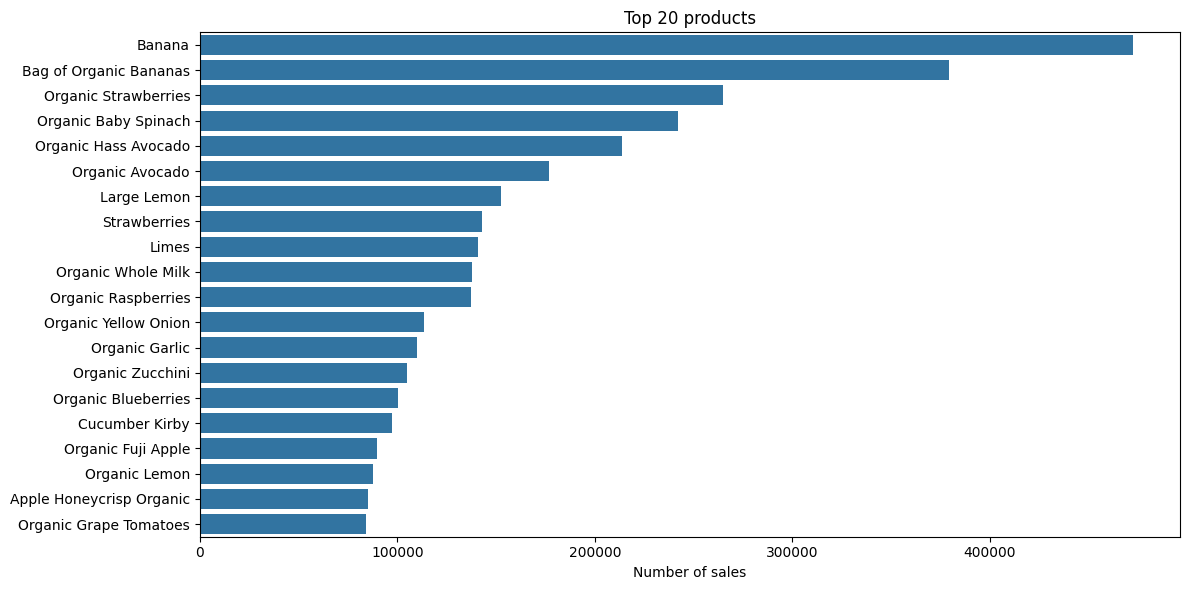

In [4]:
top_products = (order_products.groupby("product_id")["product_id"]
                .count()
                .reset_index(name="count")
                .merge(products[["product_id", "product_name"]], on="product_id")
                .sort_values("count", ascending=False)
                .head(20))

plt.figure(figsize=(12, 6))
sns.barplot(data=top_products, x="count", y="product_name")
plt.title("Top 20 products")
plt.xlabel("Number of sales")
plt.ylabel("")
plt.tight_layout()
plt.show()

Bananas are by far the most purchased product, followed by Bag of Organic Bananas and Organic Strawberries. The top 20 is dominated by fresh fruit and vegetables, with a notable preference for organic products.

This suggests that customers on Instacart tend to prioritise fresh and healthy produce. For store layout optimisation, this implies that the fresh produce section should be easily accessible and prominently placed, as it drives a large share of purchases.

## Sales by Department

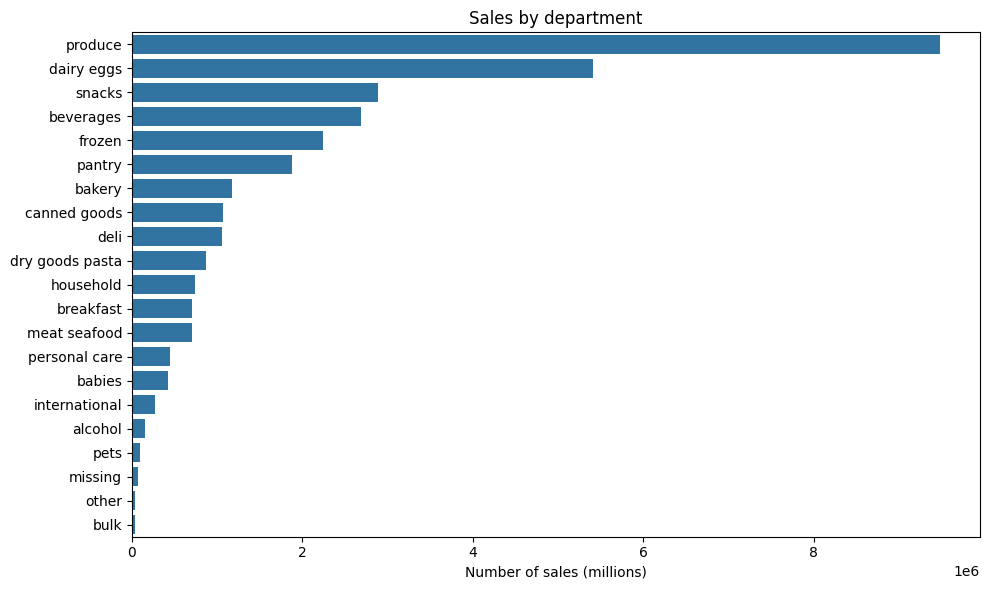

In [5]:
dept_counts = (order_products.merge(products_full, on="product_id")
               .groupby("department")["product_id"]
               .count()
               .reset_index(name="count")
               .sort_values("count", ascending=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=dept_counts, x="count", y="department")
plt.title("Sales by department")
plt.xlabel("Number of sales (millions)")
plt.ylabel("")
plt.tight_layout()
plt.show()

Produce is by far the most purchased department with around 9 million purchases, followed by dairy & eggs with around 5 million. This confirms the pattern seen in the top products chart — fresh goods dominate customer purchases. Snacks and beverages rank third and fourth, while departments like bulk, other and alcohol are rarely purchased on this platform.

For store layout, this suggests that produce and dairy should be the most accessible and central departments.

## Orders by Day of Week and Hour

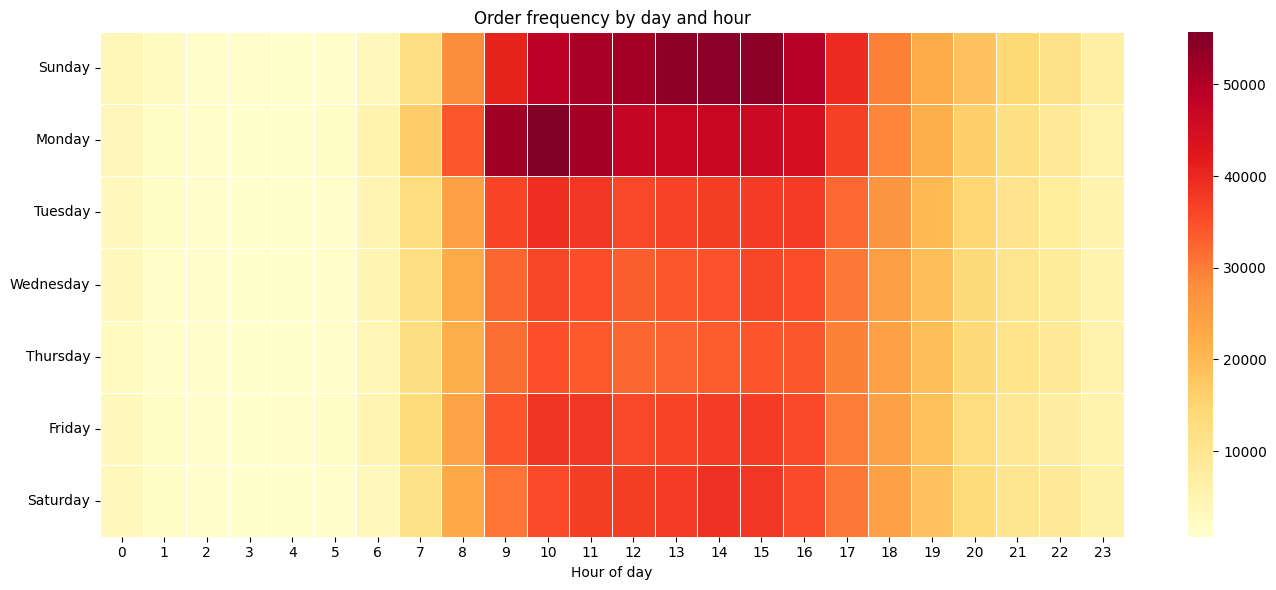

In [6]:
# Orders by day of week and hour of day
heatmap_data = orders.groupby(["order_dow", "order_hour_of_day"])["order_id"].count().unstack()

# Rename days for readability
heatmap_data.index = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap="YlOrRd", fmt="d", annot=False, linewidths=0.5)
plt.title("Order frequency by day and hour")
plt.xlabel("Hour of day")
plt.ylabel("")
plt.tight_layout()
plt.show()

Most orders are placed on Sundays and Mondays between 9 and 15 hours. This pattern likely reflects common shopping behaviour: customers plan their weekly groceries at the start of the week. Activity is low before 6am and after 10pm across all days.

For an online grocery store, this suggests that promotional campaigns and personalised recommendations should be prioritised on Sunday and Monday mornings to reach customers when they are most likely to be placing orders.

## Top 20 Products by Reorder Rate

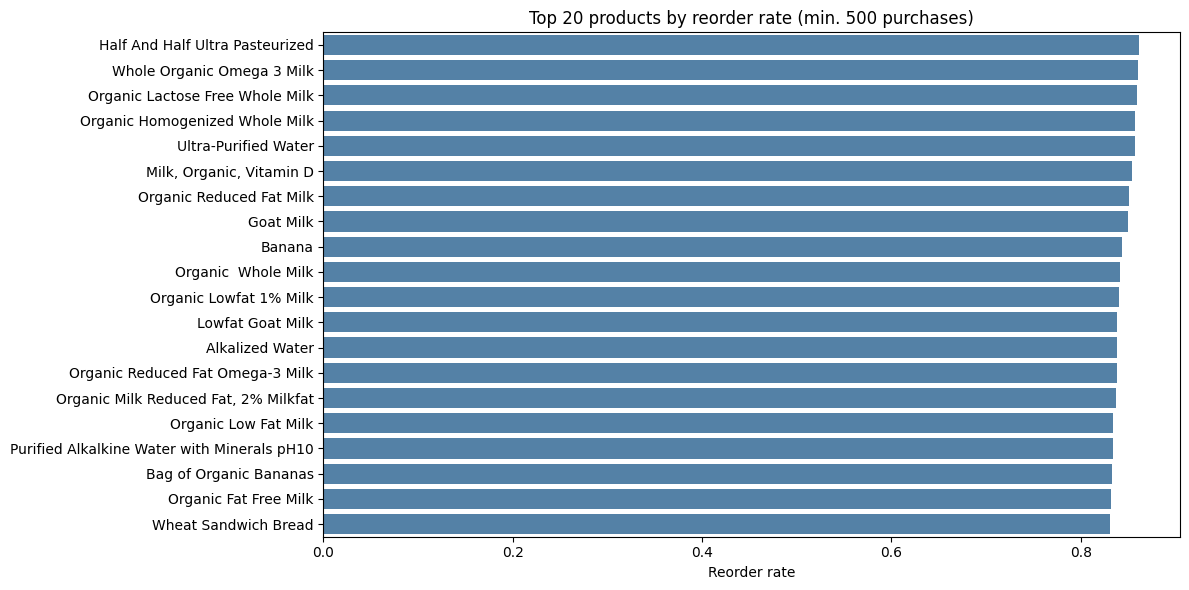

In [7]:
# Reorder rate per product
reorder_rate = (order_products.groupby("product_id")["reordered"]
                .mean()
                .reset_index()
                .rename(columns={"reordered": "reorder_rate"}))

# Merge with product names
reorder_rate = reorder_rate.merge(products[["product_id", "product_name"]], on="product_id")

# Only products with at least 500 purchases
product_counts = order_products.groupby("product_id")["product_id"].count()
popular_products = product_counts[product_counts >= 500].index

reorder_rate_filtered = reorder_rate[reorder_rate["product_id"].isin(popular_products)]
top_reorder = reorder_rate_filtered.sort_values("reorder_rate", ascending=False).head(20)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_reorder, x="reorder_rate", y="product_name", color="steelblue")
plt.title("Top 20 products by reorder rate (min. 500 purchases)")
plt.xlabel("Reorder rate")
plt.ylabel("")
plt.tight_layout()
plt.show()

Products with a reorder rate above 0.8 are almost exclusively everyday staples such as milk, water and bananas. This means that over 80% of purchases of these products are repeat orders from returning customers.

This is a strong signal for customer loyalty at the product level. For an online grocery store, these products are ideal candidates for subscription models or automatic reorder reminders, as customers buy them repeatedly and predictably.